In [10]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Function to read the mapping from Excel
def read_mapping_from_excel(file_path):
    # Read the Excel file, assuming the mapping is in the first sheet
    mapping_df = pd.read_excel(file_path, sheet_name=0)
    
    # Create a dictionary mapping MagSusRecord to Trench
    record_to_trench_map = dict(zip(mapping_df['magsus_rec_id'], mapping_df['trench']))
    
    return record_to_trench_map

# Function to process a single CSV file
def process_csv(file_path, record_id, record_to_trench_map):
    # Read the CSV file, skipping first two and last three lines
    data = pd.read_csv(file_path, skiprows=3, skipfooter=3, engine='python')
    
    # Extract relevant columns
    data = data.iloc[:, [0, 1]]  # Columns: scan_idx and susceptibility
    data.columns = ['scan_idx', 'susceptibility']
    
    # Add Record_ID and Trench_ID
    data['record_id'] = record_id
    data['trench_id'] = record_to_trench_map.get(record_id, 'Unknown')
    
    return data[['record_id', 'trench_id', 'scan_idx', 'susceptibility']]

# Read the mapping from the Excel file
excel_path = '../Data/MagSusMap.xlsx'
record_to_trench_map = read_mapping_from_excel(excel_path)

# List of files and corresponding record IDs
files = []

# Base path for the data folder
base_path = '../Data/kt20_0467/'

# Loop over each row in the mapping DataFrame
for record_number in record_to_trench_map.keys():
    folder_name = f"{record_number}"     # Create the folder name from the record number
    file_name = f"record_scanner_10khz_{record_number}.csv"  # Create the CSV file name
    file_path = f"{base_path}{folder_name}/{file_name}"  # Construct the full file path
    
    # Append the file path and record number as a tuple to the list
    files.append((file_path, record_number))

# Process all files and concatenate the results
magsus = pd.concat([process_csv(file, record_id, record_to_trench_map) for file, record_id in files])

# Display the combined DataFrame
print(magsus)


    record_id  trench_id  scan_idx  susceptibility
0           8          1         1          0.0000
1           8          1         2          0.0055
2           8          1         3          0.0180
3           8          1         4          0.0413
4           8          1         5          0.0415
..        ...        ...       ...             ...
43         64          8        44          0.0174
44         64          8        45          0.0091
45         64          8        46          0.0442
46         64          8        47          0.0391
47         64          8        48          0.0252

[1737 rows x 4 columns]


In [3]:
# depth data

trench_map_depth = pd.read_excel(excel_path)

# Create a dictionary with keys as (trench_id, record_id) and values as MaxDepth_cm
trench_depths = trench_map_depth.set_index(['trench', 'magsus_rec_id'])['max_dbs_cm'].to_dict()

# this function produces depth sequences assuming a linear relationship between 
# scan index (essentially time-series index) and physical depth along the 
# profile wall

def add_depth_column(df, trench_depths):
    """
    Adds a depth column to the DataFrame based on the scan index and the given top/bottom depths for each trench.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing magnetic susceptibility scan data.
    trench_depths (dict): Dictionary with (trench_id, record_id) as keys and MaxDepth_cm as values.
    
    Returns:
    pd.DataFrame: DataFrame with an additional column 'depth' representing the calculated depth for each scan.
    """
    def calculate_depth(row):
        # Get the bottom depth for the current trench and record
        max_depth = trench_depths[(row['trench_id'], row['record_id'])]
        
        # Assuming top_depth is 0 for all trenches
        top_depth = 0.0
        
        # Calculate the total number of scans in this trench's record
        max_scan_idx = df[(df['trench_id'] == row['trench_id']) & 
                          (df['record_id'] == row['record_id'])]['scan_idx'].max()
        
        # Calculate depth increment per scan index
        depth_increment = (max_depth - top_depth) / (max_scan_idx - 1)
        
        # Calculate the depth for the current scan index
        depth = top_depth + (row['scan_idx'] - 1) * depth_increment
        
        return depth

    # Apply the calculate_depth function to each row and add the resulting column to the dataframe
    df['depth'] = df.apply(calculate_depth, axis=1)
    
    return df

magsus = add_depth_column(magsus, trench_depths)
magsus.to_csv('../Output/magsus_scans.csv', index=False)
magsus

,record_id,trench_id,scan_idx,susceptibility,depth
0,8,1,1,0.0000,0.000000
1,8,1,2,0.0055,1.774194
2,8,1,3,0.0180,3.548387
3,8,1,4,0.0413,5.322581
4,8,1,5,0.0415,7.096774
...,...,...,...,...,...
43,64,8,44,0.0174,94.234043
44,64,8,45,0.0091,96.425532
45,64,8,46,0.0442,98.617021
46,64,8,47,0.0391,100.808511


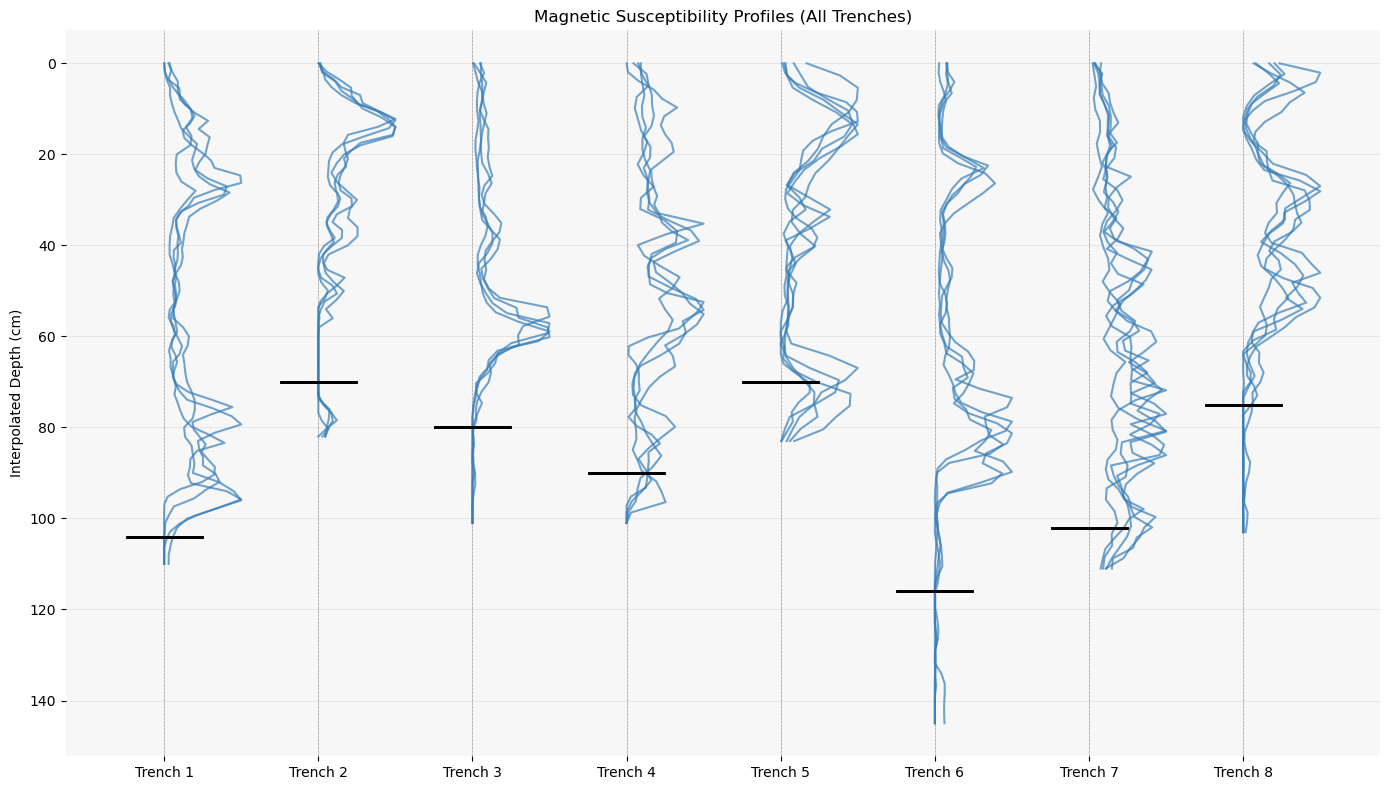

In [ ]:
# Normalize susceptibility values for each record
def normalize_susceptibility(data):
    data['susceptibility'] = data.groupby('record_id')['susceptibility'].transform(lambda x: x / x.max())
    return data

# Normalize the magsus DataFrame
magsus = normalize_susceptibility(magsus)

# Sort the magsus DataFrame by trench_id and record_id
magsus = magsus.sort_values(by=['trench_id', 'record_id', 'scan_idx'])

# Create a figure
fig, ax = plt.subplots(figsize=(14, 8))

# Define a single color for all plots
uniform_color = '#377eb8'

# Plot each trench
offsets = []  # To store offsets for x-ticks
for i, trench in enumerate(magsus['trench_id'].unique()):
    trench_data = magsus[magsus['trench_id'] == trench]
    
    # Get unique record IDs for this trench
    record_ids = trench_data['record_id'].unique()
    
    # Horizontal offset for separating trenches
    offset = i * 2  # Adjust spacing as needed
    offsets.append(offset)
    
    # Add vertical zero line for this trench
    ax.axvline(x=offset, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
    
    for record_id in record_ids:
        record_data = trench_data[trench_data['record_id'] == record_id]
        
        # Plot each profile with an offset and transparency
        ax.plot(record_data['susceptibility'] + offset,
                record_data['depth'],
                color=uniform_color,
                alpha=0.7)  # Transparency
        
        # Get the sterile depth for this trench and record_id
        sterile_depth = trench_map_depth[(trench_map_depth['trench'] == trench) & 
                                         (trench_map_depth['magsus_rec_id'] == record_id)]['sterile_dbs_cm'].values
        
        # If sterile depth exists, plot a short horizontal line at that depth
        if len(sterile_depth) > 0:
            ax.hlines(y=sterile_depth, xmin=offset - 0.5, xmax=offset + 0.5, color='black', linewidth=2)

# Set the x-ticks to the trench offsets and label them with the trench numbers
ax.set_xticks(offsets)
ax.set_xticklabels([f'Trench {trench}' for trench in magsus['trench_id'].unique()])

# Invert y-axis to have depth increase downward
ax.invert_yaxis()

# Set labels and title
ax.set_ylabel('Interpolated Depth (cm)')
ax.set_xlabel('')
ax.set_title('Magnetic Susceptibility Profiles (All Trenches)')

# Apply minimal theme styling (like ggplot2's theme_minimal)
ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.7, alpha=0.5)
ax.set_facecolor('#f7f7f7')  # Light grey background
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Adjust the layout and show the plot
plt.tight_layout()

# Save the plot
plt.savefig('../Output/magnetic_susceptibility_profiles.png', dpi=300, bbox_inches='tight', format='png')
plt.savefig('../Output/magnetic_susceptibility_profiles.pdf', dpi=300, bbox_inches='tight', format='pdf')


# Display it
plt.show()


In [ ]:
# Normalize susceptibility values for each record
def normalize_susceptibility(data):
    data['susceptibility'] = data.groupby('record_id')['susceptibility'].transform(lambda x: x / x.max())
    return data

# Normalize the magsus DataFrame
magsus = normalize_susceptibility(magsus)

# Sort the magsus DataFrame by trench_id and record_id
magsus = magsus.sort_values(by=['trench_id', 'record_id', 'scan_idx'])

# Define a single color for all plots
uniform_color = '#377eb8'

# Iterate over each trench and plot separately
for trench in magsus['trench_id'].unique():
    trench_data = magsus[magsus['trench_id'] == trench]
    
    # Create a figure for each trench
    fig, ax = plt.subplots(figsize=(6, 8))  # Adjust the size if needed
    
    # Get unique record IDs for this trench
    record_ids = trench_data['record_id'].unique()
    
    for record_id in record_ids:
        record_data = trench_data[trench_data['record_id'] == record_id]
        
        # Plot each profile without an offset and with transparency
        ax.plot(record_data['susceptibility'],
                record_data['depth'],
                color=uniform_color,
                alpha=0.7)  # Transparency
        
        # Get the sterile depth for this trench and record_id
        sterile_depth = trench_map_depth[(trench_map_depth['trench'] == trench) & 
                                         (trench_map_depth['magsus_rec_id'] == record_id)]['sterile_dbs_cm'].values
        
        # If sterile depth exists, plot a short horizontal line at that depth
        if len(sterile_depth) > 0:
            ax.hlines(y=sterile_depth, xmin=-0.5, xmax=0.5, color='black', linewidth=2)
    
    # Invert y-axis to have depth increase downward
    ax.invert_yaxis()

    # Set labels and title
    ax.set_ylabel('Interpolated Depth (cm)')
    ax.set_xlabel('Normalized Magnetic Susceptibility')
    ax.set_title(f'Magnetic Susceptibility Profile - Trench {trench}')

    # Apply minimal theme styling (like ggplot2's theme_minimal)
    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.7, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Save the plot as a PDF and SVG with a transparent background
    plt.savefig(f'../Output/Trench_{trench}_MagSus_Profile.pdf', dpi=300, bbox_inches='tight', format='pdf', transparent=True)
    plt.savefig(f'../Output/Trench_{trench}_MagSus_Profile.svg', dpi=300, bbox_inches='tight', format='svg', transparent=True)

    # Close the figure to avoid display
    plt.close(fig)


In [6]:
# Load the CSV file into a Pandas DataFrame
file_path = '../Data/kkpp24_c14.csv'
c14_data = pd.read_csv(file_path)

# Extract 'trench' and 'depth' from 'sample_id' and convert them to integers
import re

c14_data['trench'] = c14_data['sample_id'].apply(lambda x: int(x.split('_')[1]))  # Extract trench as an integer
c14_data['depth'] = c14_data['sample_id'].apply(lambda x: int(re.sub(r'\D', '', x.split('_')[2])))  # Remove non-numeric characters from depth


# Step 3: Display the updated DataFrame
print(c14_data.head())


   ugams     sample_id  material  d13C_ppm  ybp_14C  error_14C    pMC  \
0  73631   KKPP24_1_10  sediment    -24.83     1120       20.0  86.95   
1  73632   KKPP24_1_50  sediment    -26.35     4340       25.0  58.27   
2  73633  KKPP24_1_100  sediment    -26.63     3090       20.0  68.10   
3  73634   KKPP24_2_10  sediment    -23.75     1530       20.0  82.67   
4  73635   KKPP24_2_40  sediment    -27.13     4130       20.0  59.78   

   error_pmc  trench  depth  
0       0.21       1     10  
1       0.17       1     50  
2       0.18       1    100  
3       0.21       2     10  
4       0.17       2     40  


In [20]:
# Import the full module to ensure initialization code (e.g., intcal20) runs
import chronocluster.distributions

# Import the specific calibration class
from chronocluster.distributions import calrcarbon

# access calrcarbon without referring to the full namespace
intcal20 = chronocluster.distributions.intcal20  # Access the preloaded calibration curve

# Use calrcarbon directly
cal = calrcarbon(intcal20, c14_mean=1120, c14_err=20)

# Create a list of calrcarbon objects using the loaded IntCal20 calibration curve
calibrations = [calrcarbon(intcal20, c14_mean=-row['ybp_14C'], c14_err=row['error_14C']) for _, row in c14_data.iterrows()]

# get calibrated means and add them to the c14_data df
c14_data['ybp_cal']  = [round(cal.mean()) for cal in calibrations]

c14_data.to_csv('../Output/c14_data.csv', index=False)

c14_data


,ugams,sample_id,material,d13C_ppm,ybp_14C,error_14C,pMC,error_pmc,trench,depth,ybp_cal
0,73631,KKPP24_1_10,sediment,-24.83,1120,20.00,86.95,0.21,1,10,-1013
1,73632,KKPP24_1_50,sediment,-26.35,4340,25.00,58.27,0.17,1,50,-4906
2,73633,KKPP24_1_100,sediment,-26.63,3090,20.00,68.10,0.18,1,100,-3302
3,73634,KKPP24_2_10,sediment,-23.75,1530,20.00,82.67,0.21,2,10,-1400
4,73635,KKPP24_2_40,sediment,-27.13,4130,20.00,59.78,0.17,2,40,-4681
5,73636,KKPP24_2_80,sediment,-28.43,7880,30.00,37.50,0.13,2,80,-8687
6,73637,KKPP24_3_10,sediment,-19.71,950,20.00,88.87,0.21,3,10,-850
7,73638,KKPP24_3_50,sediment,-23.85,2000,20.00,77.92,0.19,3,50,-1938
8,73639,KKPP24_3_90,sediment,-25.43,3850,20.00,61.90,0.17,3,90,-4266
9,73640,KKPP24_4_10,sediment,-22.02,490,20.00,94.13,0.23,4,10,-521


In [21]:
c14_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ugams      38 non-null     int64  
 1   sample_id  38 non-null     object 
 2   material   38 non-null     object 
 3   d13C_ppm   38 non-null     float64
 4   ybp_14C    38 non-null     int64  
 5   error_14C  38 non-null     float64
 6   pMC        38 non-null     float64
 7   error_pmc  37 non-null     float64
 8   trench     38 non-null     int64  
 9   depth      38 non-null     int64  
 10  ybp_cal    38 non-null     int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 3.4+ KB


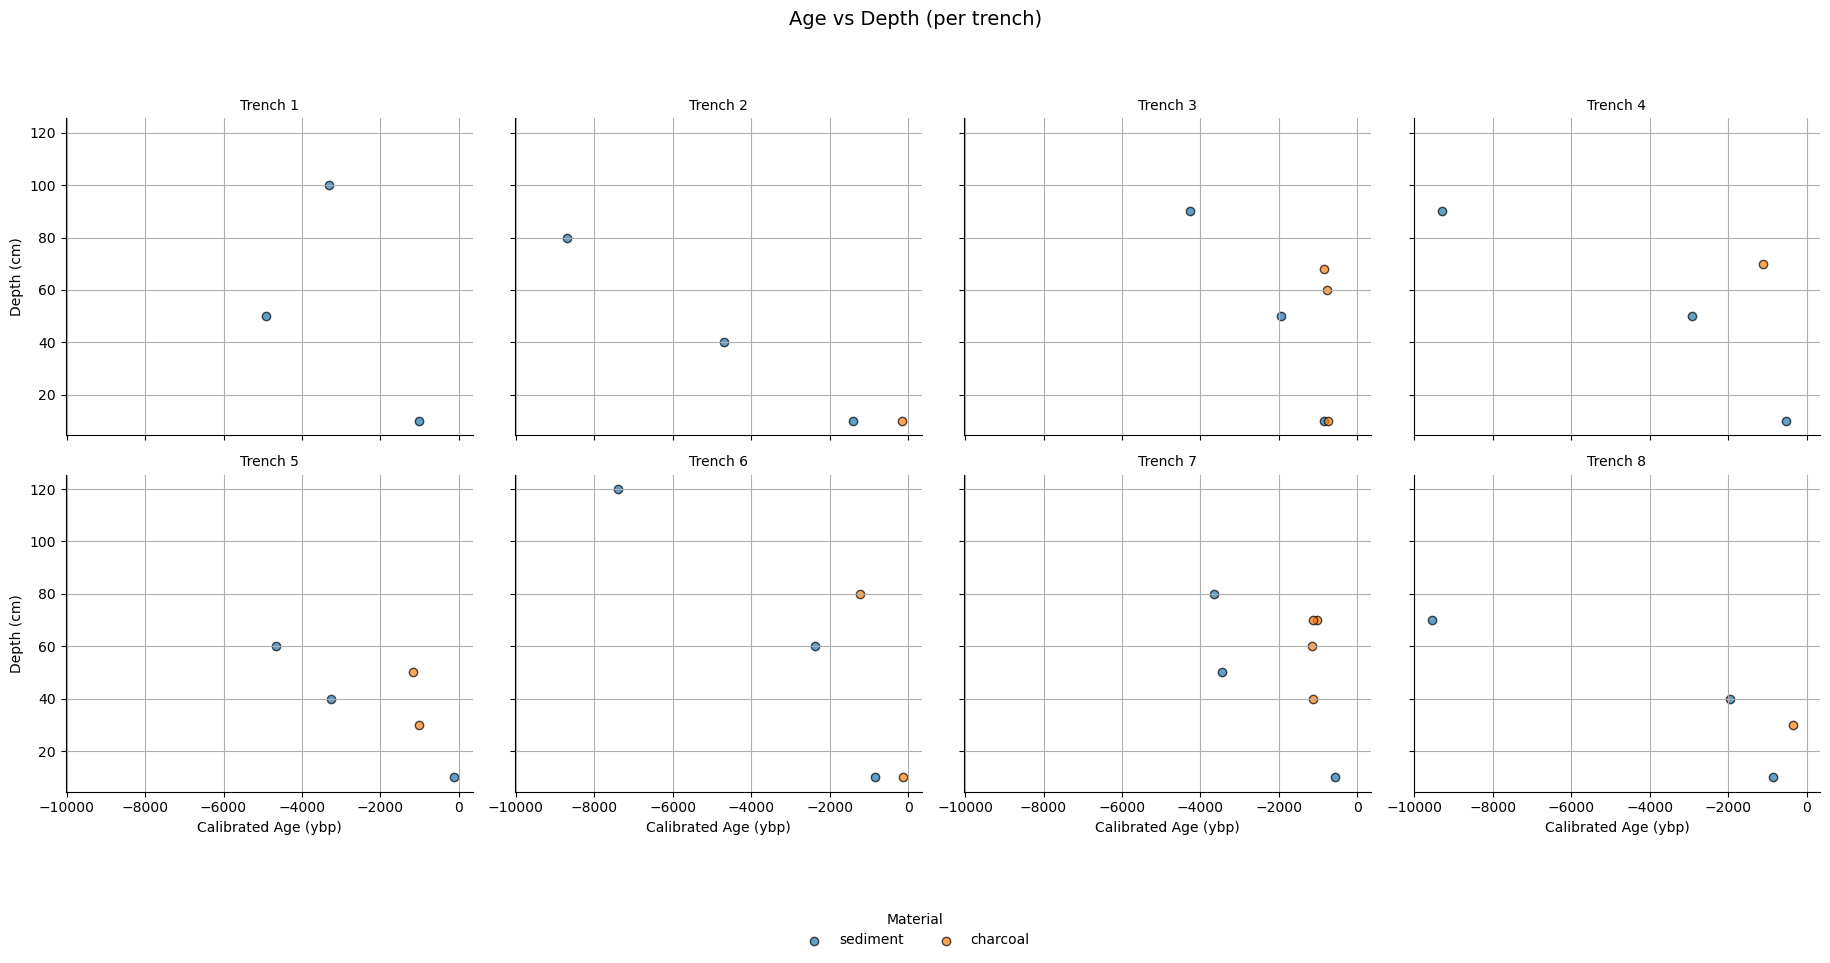

In [39]:
# Create the FacetGrid
g = sns.FacetGrid(c14_data, col="trench", hue="material", col_wrap=4, height=4, sharex=True, sharey=True)

# Plot scatter in each facet
g.map(plt.scatter, "ybp_cal", "depth", edgecolor="black", alpha=0.7)

# Set axis labels and facet titles
g.set_axis_labels("Calibrated Age (ybp)", "Depth (cm)")
g.set_titles("Trench {col_name}")

# Add a global title
plt.suptitle("Age vs Depth (per trench)", fontsize=14, y=1.05)

# Move the legend **outside the grid**.
g.add_legend(title="Material", loc='center', bbox_to_anchor=(0.5, -0.1), ncol=2)

# Add gridlines
for ax in g.axes.flat:
    ax.grid(True)

# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0, 1, 1])

# Show plot
plt.show()


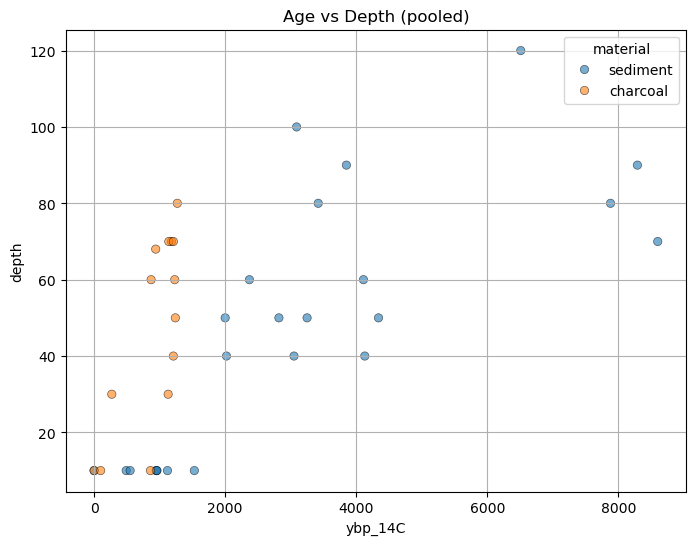

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=c14_data,
    x='ybp_14C',
    y='depth',
    hue='material',
    palette='tab10',
    edgecolor='black',
    alpha=0.6,
    ax=ax
)

ax.set_xlabel('ybp_14C')
ax.set_ylabel('depth')
ax.set_title('Age vs Depth (pooled)')

plt.grid(True)
plt.show()

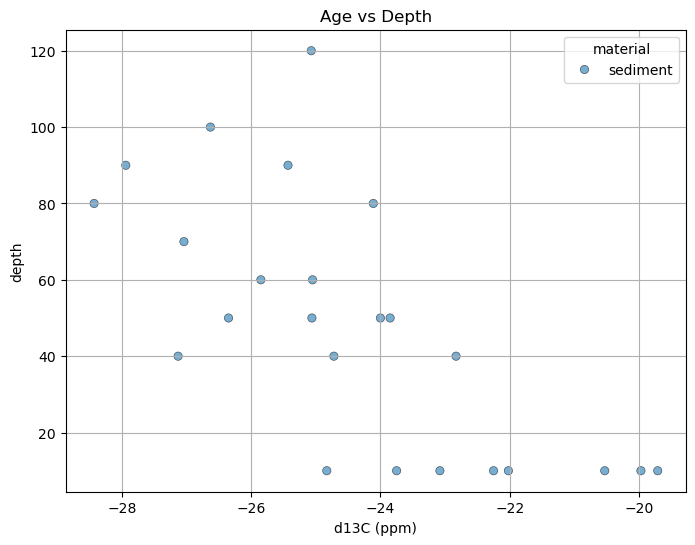

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=c14_data[c14_data['material'] == 'sediment'],
    x='d13C_ppm',
    y='depth',
    hue='material',
    palette='tab10',
    edgecolor='black',
    alpha=0.6,
    ax=ax
)

ax.set_xlabel('d13C (ppm)')
ax.set_ylabel('depth')
ax.set_title('Age vs Depth')

plt.grid(True)
plt.show()

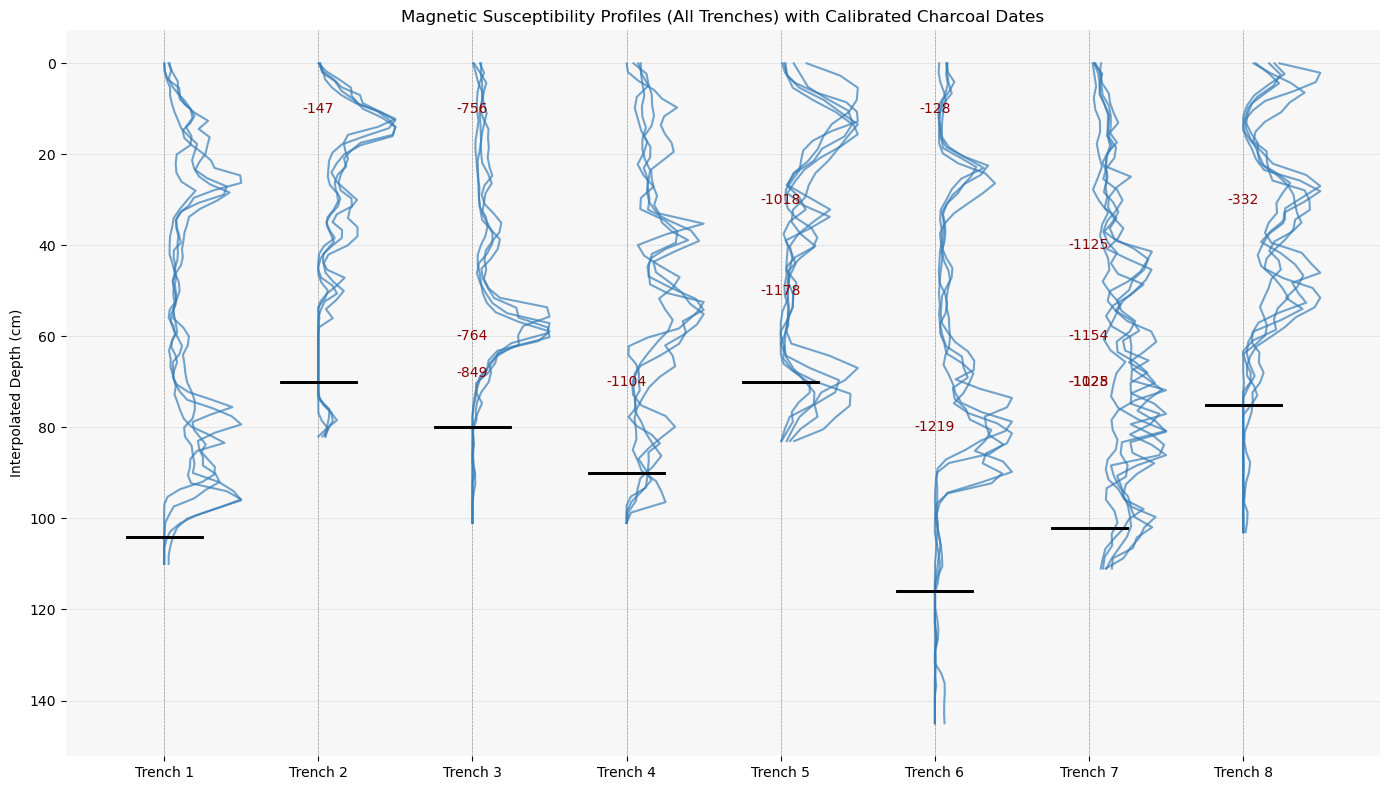

In [8]:
# Filter c14_data for charcoal dates
charcoal_data = c14_data[c14_data['material'] == 'charcoal']

# Create a figure
fig, ax = plt.subplots(figsize=(14, 8))

# Define a single color for all plots
uniform_color = '#377eb8'

# Plot each trench
offsets = []  # To store offsets for x-ticks
for i, trench in enumerate(magsus['trench_id'].unique()):
    trench_data = magsus[magsus['trench_id'] == trench]
    
    # Get unique record IDs for this trench
    record_ids = trench_data['record_id'].unique()
    
    # Horizontal offset for separating trenches
    offset = i * 2  # Adjust spacing as needed
    offsets.append(offset)
    
    # Add vertical zero line for this trench
    ax.axvline(x=offset, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
    
    for record_id in record_ids:
        record_data = trench_data[trench_data['record_id'] == record_id]
        
        # Plot each profile with an offset and transparency
        ax.plot(record_data['susceptibility'] + offset,
                record_data['depth'],
                color=uniform_color,
                alpha=0.7)  # Transparency
        
        # Get the sterile depth for this trench and record_id
        sterile_depth = trench_map_depth[(trench_map_depth['trench'] == trench) & 
                                         (trench_map_depth['magsus_rec_id'] == record_id)]['sterile_dbs_cm'].values
        
        # If sterile depth exists, plot a short horizontal line at that depth
        if len(sterile_depth) > 0:
            ax.hlines(y=sterile_depth, xmin=offset - 0.5, xmax=offset + 0.5, color='black', linewidth=2)

    # Add calibrated radiocarbon dates for charcoal material
    trench_charcoal_data = charcoal_data[charcoal_data['trench'] == trench]
    for _, row in trench_charcoal_data.iterrows():
        ax.text(x=offset, y=row['depth'], s=f"{int(row['ybp_cal'])}", 
                color='darkred', fontsize=10, ha='center', va='center')

# Set the x-ticks to the trench offsets and label them with the trench numbers
ax.set_xticks(offsets)
ax.set_xticklabels([f'Trench {trench}' for trench in magsus['trench_id'].unique()])

# Invert y-axis to have depth increase downward
ax.invert_yaxis()

# Set labels and title
ax.set_ylabel('Interpolated Depth (cm)')
ax.set_xlabel('')
ax.set_title('Magnetic Susceptibility Profiles (All Trenches) with Calibrated Charcoal Dates')

# Apply minimal theme styling (like ggplot2's theme_minimal)
ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.7, alpha=0.5)
ax.set_facecolor('#f7f7f7')  # Light grey background
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Adjust the layout and show the plot
plt.tight_layout()

# Save the plot
plt.savefig('../Output/magnetic_susceptibility_profiles_with_charcoal_dates.png', dpi=300, bbox_inches='tight', format='png')
plt.savefig('../Output/magnetic_susceptibility_profiles_with_charcoal_dates.pdf', dpi=300, bbox_inches='tight', format='pdf')

# Display it
plt.show()
